# (코드 워크아웃) 신용카드 사기 거래 탐지

극도로 불균형을 이루는 두 개의 범주로 구성된 신용카드 거래 데이터를 사용하여 사기 탐지 분류 모델을 구축한다.

1. 먼저 데이터의 불균형 문제를 확인한 뒤, 언더샘플링 기법으로 균형 잡힌 데이터셋을 생성한다.
2. 로지스틱 회귀 모델에 `GridSearchCV`를 적용하여 최적의 하이퍼파라미터(`C`, `l1_ratio`)를 탐색하고, 언더샘플 데이터와 전체 편향 데이터 각각에서 모델을 학습시켜 성능을 비교한다.
3. 재현율(recall)을 핵심 평가 지표로 삼아 혼동 행렬과 정밀도-재현율 곡선으로 모델을 평가하며, 분류 기준값(threshold)을 조정하여 정밀도와 재현율 간의 균형을 탐색한다.

**참고사항**

[In depth skewed data classif. (93% recall acc now)](https://www.kaggle.com/code/joparga3/in-depth-skewed-data-classif-93-recall-acc-now/notebook)의 내용을 참고하였다.

**기본 설정**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 데이터 탐색

**데이터셋 불러오기**

이 데이터셋은 유럽 카드 소지자의 2013년 9월 이틀간 신용카드 거래 기록이다. 
총 284,807건의 거래 중 492건이 사기(fraud)로, 양성 클래스 비율이 약 0.173%에 불과한 극도로 불균형한 데이터이다.
PCA 변환으로 익명화된 28개의 피처(`V1`~`V28`)와, 변환되지 않은 `Time`(첫 거래 이후 경과 초), `Amount`(거래 금액), 그리고 타깃 변수 `Class`(0: 정상, 1: 사기)로 구성된다.

**주의사항**

1. 아래 코드는 `creditcard.csv` 파일이 현재작업디렉토리(cwd)의 하위 폴더인 `datasets`에 저장되어 있다고 가정한다.
2. `creditcard.csv` 파일은 [In depth skewed data classif. (93% recall acc now)](https://www.kaggle.com/code/joparga3/in-depth-skewed-data-classif-93-recall-acc-now/input)에서 다운로드 받을 수 있다.



In [3]:
from pathlib import Path

data_credit = pd.read_csv(Path("datasets") / "creditcard.csv")
data_credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [26]:
data_credit.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**타깃 특성**

타깃 특성은 `Class` 열이다. 값이 0이면 정상 거래, 1이면 사기 거래를 나타낸다.

In [27]:
count_classes = data_credit['Class'].value_counts()
count_classes


Class
0    284315
1       492
Name: count, dtype: int64

사기 거래 비율이 0.173% 정도로 극도로 낮다.

In [28]:
count_classes[1] / data_credit.shape[0]

np.float64(0.001727485630620034)

막대 그래프로 그리면 정상 거래와 사기 거래의 차이가 선명하게 보여진다.

Text(0, 0.5, 'Frequency')

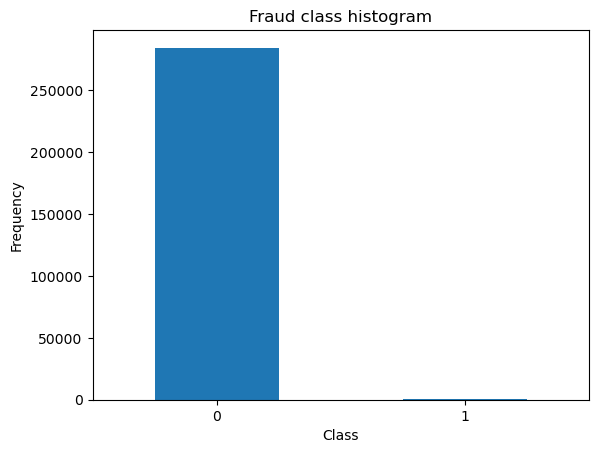

In [29]:
count_classes.plot(kind = 'bar', rot=0)

plt.title("Fraud class histogram")
plt.xlabel("Class")
plt.ylabel("Frequency")

## 훈련셋 준비

### 전처리

타 특성들과의 단위를 맞추기 위해 `Amount` 특성을 표준화 스케일링을 적용한다.

In [30]:
data_credit['Amount']

0         149.62
1           2.69
2         378.66
3         123.50
4          69.99
           ...  
284802      0.77
284803     24.79
284804     67.88
284805     10.00
284806    217.00
Name: Amount, Length: 284807, dtype: float64

In [31]:
from sklearn.preprocessing import StandardScaler

data_credit['normAmount'] = StandardScaler().fit_transform(data_credit['Amount'].values.reshape(-1, 1))
data_credit = data_credit.drop(['Time','Amount'],axis=1)
data_credit.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,normAmount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403


### 언더 샘플링

타깃 범주가 극도로 불균형을 이루는 훈련셋으로 학습시간 분류 모델은
정확도(accuracy)를 사용하여 평가하면 안된다.
불균형을 고려하여 분류 문제에 접근하는 방법은 여러 가지가 있다.

- 더 많은 데이터 수집
    - 가능한 경우에만 효율적이다. 이 경우엔 불가능하다.
- 성능 지표 변경
    - 혼동 행렬(confusion matrix)을 사용하여 정밀도(Precision), 재현율(Recall)을 계산한다.
    - F1 점수 (정밀도와 재현율의 가중 평균)
    - ROC 곡선: 민감도/특이도 비율을 계산한다.
- 데이터셋 리샘플링
    - 기본적으로 데이터를 약 50-50 비율로 처리하는 방법이다.
    - 오버샘플링(OVER-sampling): 소수 클래스의 복사본을 추가한다. 데이터가 적을 때 적합하다.
    - 언더샘플링(UNDER-sampling): 다수 클래스의 인스턴스를 삭제한다. 데이터가 많을 때 적합하다.

신용카드 데이터셋은 충분히 크다. 
따라서 언더샘플링 기법을 적용하여 훈련 시킨 분류 모델의 성능과
전체 데이터셋을 이용하여 훈련 시킨 분류 모델의 성능을 비교 평가한다.
언더샘플링은 범주별 데이터의 비율을 균등하게 만드는 기법이다.
여기서는 두 범주의 데이터를 50/50 비율을 만들어야 한다.
이를 위해 다수 범주에서 소수 범주 크기만큼의 샘플을 무작위로 선택한다.

In [ ]:
# 소수 클래스(사기 거래)의 인덱스와 개수
fraud_indices = data_credit[data_credit.Class == 1].index
number_records_fraud = len(fraud_indices)

# 다수 클래스(정상 거래)의 인덱스
normal_indices = data_credit[data_credit.Class == 0].index

# 다수 클래스 인덱스에서 소수 클래스 개수만큼 무작위 선택
random_normal_indices = normal_indices.to_series().sample(number_records_fraud, replace=False).index

# 두 인덱스를 합쳐 언더샘플 인덱스 생성
under_sample_indices = fraud_indices.append(random_normal_indices)

# 언더샘플 데이터셋
under_sample_data = data_credit.loc[under_sample_indices, :]

두 범주가 5대 5의 비율로 구성되었다.

In [36]:
print("정상 거래 비율: ", len(under_sample_data[under_sample_data.Class == 0])/len(under_sample_data))
print("사기 거래 비율: ", len(under_sample_data[under_sample_data.Class == 1])/len(under_sample_data))
print("언더샘플 데이터셋 총 거래 수: ", len(under_sample_data))

Percentage of normal transactions:  0.5
Percentage of fraud transactions:  0.5
Total number of transactions in resampled data:  984


### 입력 데이터셋/타깃셋

전체 데이터셋과 언더샘플 데이터셋 모두 입력 데이터셋과 타깃셋으로 특성을 `Class` 특성을 기준으로 분할한다.

- 전체 데이터셋 분할

In [33]:
X = data_credit.drop(columns=['Class'])
y = data_credit[['Class']]

- 언더샘플 데이터셋 분할

In [35]:
X_undersample = under_sample_data.drop(columns=['Class'])
y_undersample = under_sample_data[['Class']]

### 훈련셋/테스트셋 분할

전체 데이터셋과 언더샘플 데이터셋 모두 7대 3의 비율로 훈련셋과 테스트셋으로 분할한다.

In [37]:
from sklearn.model_selection import train_test_split

print("\n전체 데이터셋 분할")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=17)

print("훈련셋: ", len(X_train))
print("테스트셋: ", len(X_test))

print("\n언더샘플 데이터셋 분할")
X_train_undersample, X_test_undersample, y_train_undersample, y_test_undersample = train_test_split(X_undersample,
                                                                                                    y_undersample,
                                                                                                    test_size=0.3,
                                                                                                    random_state=17)
print("훈련셋: ", len(X_train_undersample))
print("테스트셋: ", len(X_test_undersample))


전체 데이터셋 분할
훈련셋:  199364
테스트셋:  85443

언더샘플 데이터셋 분할
훈련셋:  688
테스트셋:  296


## 로지스틱 회귀 분류기: 언더샘플 데이터

50 대 50으로 균형을 맞춘 언더샘플 데이터셋에 대해 로지스트 회귀 분류기를 훈련시킨다.
나중에 균형이 맞지 않는 전체 데이터셋을 대상으로 훈련시킨 로지스틱 회귀 분류기와의 성능 비교를 위해
정확도가 아닌 재현율을 기준으로 모델을 평가한다.

재현율을 성능 평가 기준으로 사용하는 이유는 
신용카드 사기 거래를 탐지하지 못했을 때의 피해가
정상 거래를 사기 거래로 탐지했을 때의 피해보다 훨씨 크기 때문이다.
즉, 사기 거래를 사기 거래로 탐지하는 확률인 재현율이 정밀도보다 중요하다.

### 그리드 탐색 훈련

그리드 탐색을 통해 최적의 하이퍼파라미터 조합을 확인한다.
여기서는 규제 강도 `C`와 L1 규제 비율 `l1_ratio` 하이퍼파라미터를 탐색한다.
성능평가 기준은 재현율(`recall`)로 지정된다.

단, 여기서는 활용 예제를 위해 몇 개의 경우만 탐색한다.
실전용인 경우에는 보다 많은 하이퍼파라미터 조합을 확인해야 한다.

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import recall_score, ConfusionMatrixDisplay, PrecisionRecallDisplay
from sklearn.model_selection import GridSearchCV

lr = LogisticRegression(solver='saga', max_iter=7000)
param_grid = {'C': [0.1, 0.5, 1, 10],
              'l1_ratio': [1, 0.5, 0],}

grid = GridSearchCV(lr, param_grid, cv=3, scoring='recall', verbose=3)
grid.fit(X_train_undersample, y_train_undersample.values.ravel())

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV 1/3] END .................C=0.1, l1_ratio=1;, score=0.907 total time=   0.0s
[CV 2/3] END .................C=0.1, l1_ratio=1;, score=0.923 total time=   0.0s
[CV 3/3] END .................C=0.1, l1_ratio=1;, score=0.839 total time=   0.0s
[CV 1/3] END ...............C=0.1, l1_ratio=0.5;, score=0.932 total time=   0.0s
[CV 2/3] END ...............C=0.1, l1_ratio=0.5;, score=0.932 total time=   0.0s
[CV 3/3] END ...............C=0.1, l1_ratio=0.5;, score=0.839 total time=   0.0s
[CV 1/3] END .................C=0.1, l1_ratio=0;, score=0.924 total time=   0.0s
[CV 2/3] END .................C=0.1, l1_ratio=0;, score=0.940 total time=   0.0s
[CV 3/3] END .................C=0.1, l1_ratio=0;, score=0.856 total time=   0.0s
[CV 1/3] END .................C=0.5, l1_ratio=1;, score=0.941 total time=   0.1s
[CV 2/3] END .................C=0.5, l1_ratio=1;, score=0.940 total time=   0.1s
[CV 3/3] END .................C=0.5, l1_ratio=1;

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...solver='saga')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 0.5, ...], 'l1_ratio': [1, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : th

그리드 탐색 과정에서 사용된 3겹 교차검증에서 평가된 검증셋에 대한 최고 재현율은 다음과 같다.

In [39]:
grid.best_score_

np.float64(0.9207590902506156)

확인된 최적의 하이퍼파라미터 조합은 다음과 같다.

In [40]:
grid.best_params_

{'C': 1, 'l1_ratio': 1}

두 하이퍼파라리터를 기억해둔다.

In [44]:
best_c = grid.best_params_['C']
best_l1_ratio = grid.best_params_['l1_ratio']

### 혼동 행렬

훈련된 최적의 모델을 이용하여 언더샘플 테스트셋에 대한 예측값을 계산한 다음에
혼동행렬을 시각화한다.
재현율이 95%에 육박할 정도로 꽤 높다.

언더샘플 테스트셋에 대한 재현율: 0.9496


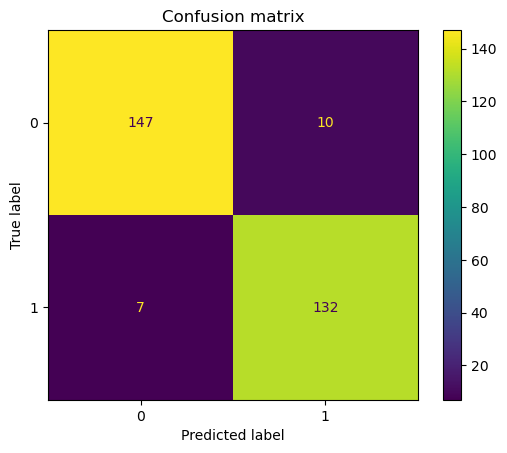

In [46]:
lr = grid.best_estimator_
y_pred_undersample = lr.predict(X_test_undersample)

print(f"언더샘플 테스트셋에 대한 재현율: {recall_score(y_test_undersample, y_pred_undersample):.4f}")

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test_undersample, y_pred_undersample)
plt.title('Confusion matrix')
plt.show()

이번에는 학습된 모델을 전체 테스트 데이터에 적용해서 재현율을 확인하며
94% 정도로 여전히 꽤 높다.
언더샘플링 기법을 적용하여 훈련시킨 모델의 재현율이 매우 높다.

전체 테스트셋에 대한 재현율: 0.9384


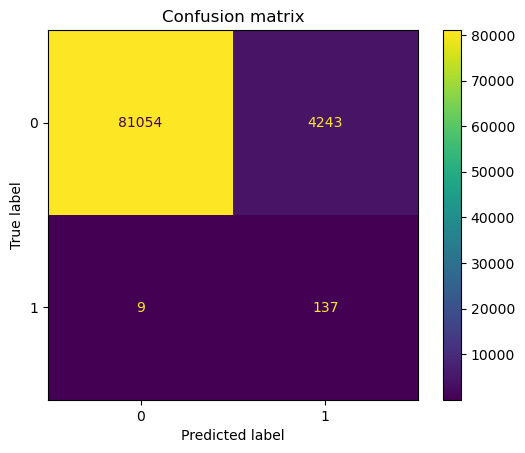

In [48]:
# Apply the fitted model on the whole test data
y_pred = lr.predict(X_test)

print(f"전체 테스트셋에 대한 재현율: {recall_score(y_test, y_pred):.4f}")

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion matrix')
plt.show()

### 정밀도/재현율 트레이드오프

재현율과 정밀도의 트레이드오프 관계로 인해 정밀도는 3.1% 정도로 매우 낮다.

In [50]:
from sklearn.metrics import precision_score

print(f"전체 테스트셋에 대한 정밀도: {precision_score(y_test, y_pred):.4f}")

전체 테스트셋에 대한 정밀도: 0.0313


아래 코드는 정밀도와 재현율의 트레이드오프 관계를 그래프로 그린다.

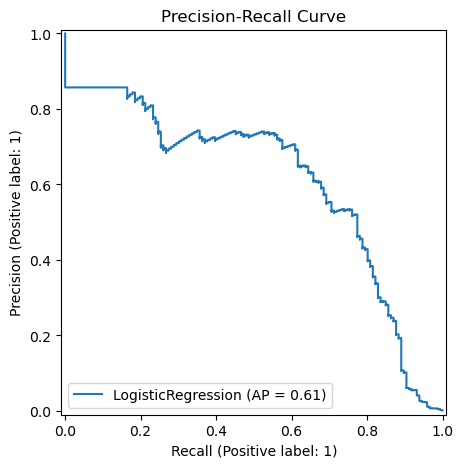

In [52]:
fig, ax = plt.subplots(figsize=(5, 5))

PrecisionRecallDisplay.from_estimator(lr, X_test, y_test.values.ravel(), ax=ax)

ax.set_title('Precision-Recall Curve')
plt.show()

## 로지스틱 회귀 분류기: 편향된 데이터

편향된 전체 데이터에 대해 동일한 실험을 진행한다.

**주의사항**

동일한 조건으로 그리드 탐색을 실행할 수 있다.
1시간 이상 걸리기는 하지만 여유가 있다면 실행해 볼 것을 추천한다.
아래 코드에서 `enough_time = True`만 지정하면 된다.

시간 여유가 없다면 현재 코드 그대로 실행하면 된다.
그러면 이전에 언더샘플 데이터셋에 대해 찾아진 최적의 하이퍼파라미터 조합을
그대로 사용한다. 

In [53]:
enough_time = False

if enough_time:
    lr = LogisticRegression(solver='saga', max_iter=7000)
    param_grid = {'C': [0.1, 0.5, 1, 10],
                'l1_ratio': [1, 0.5, 0],}

    grid_full = GridSearchCV(lr, param_grid, cv=3, scoring='recall', verbose=3)
    grid_full.fit(X_train, y_train.values.ravel())

    best_c_full = grid_full.best_params_['C']
    best_l1_ratio_full = grid_full.best_params_['l1_ratio']

    lr_full = grid_full.best_estimator_
else:
    best_c_full = best_c
    best_l1_ratio_full = best_l1_ratio

    lr_full = LogisticRegression(C=best_c_full, l1_ratio=best_l1_ratio_full, solver='saga', max_iter=7000)
    lr_full.fit(X_train, y_train.values.ravel())

편향된 데이터셋으로 훈련된 모델의 재현율이 63.7% 정도로 매우 낮게 계산된다.

테스트셋 재현율: 0.6370


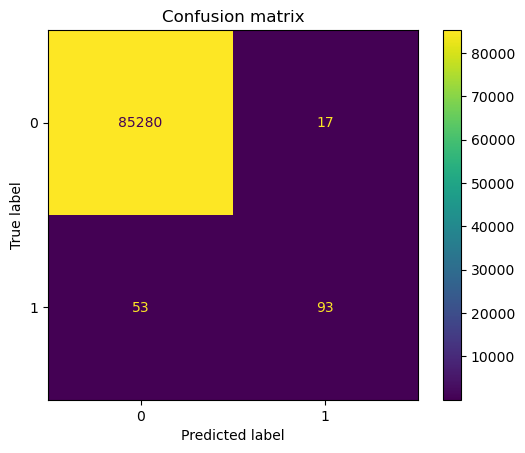

In [55]:
y_pred_full = lr_full.predict(X_test)

print(f"테스트셋 재현율: {recall_score(y_test, y_pred_full):.4f}")

# 혼동 행렬 시각화
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_full)
plt.title('Confusion matrix')
plt.show()

정밀도 대 재현율의 트레이드오프 관계 그래프는 다음과 같다.

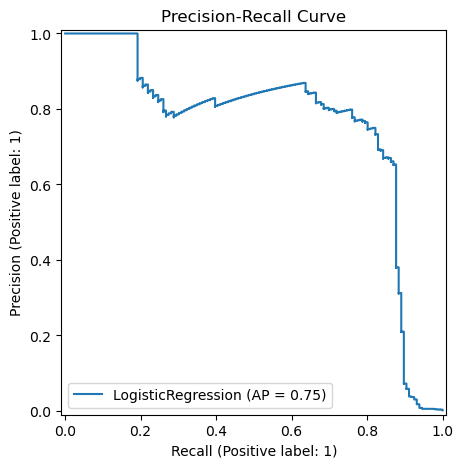

In [56]:
fig, ax = plt.subplots(figsize=(5, 5))

PrecisionRecallDisplay.from_estimator(lr_full, X_test, y_test.values.ravel(), ax=ax)

ax.set_title('Precision-Recall Curve')
plt.show()

## 결정 임곗값에 따른 재현율 변화

데이터를 언더샘플링하면 알고리즘이 신용카드 사기 거래 탐지에서 훨씬 더 나은 성능을 보인다는 것을 확인했다.
여기서는 결정 임곗값을 변경할 때의 재현율의 변화를 살펴본다.

사이킷런의 로지스틱 회귀 모델의 `predict()` 메서드는 `predict_proba()`가 계산하는
확률값이 0.5 이하인 경우 음성(0에 해당)으로 판정한다.
즉, `predict_proba()`를 결정 함수로 사용한다.

아래 코드는 결정 함수가 계산하는 확률값의 임곗값을 0.1부터 0.9까지 변화시킬 때
언더샘플로 훈련된 모델의 재현율의 변화를 혼동행렬의 변화로 보여준다.

- 결정 임곗값을 0.9까지 올리면 재현율이 89%까지 떨어진다.

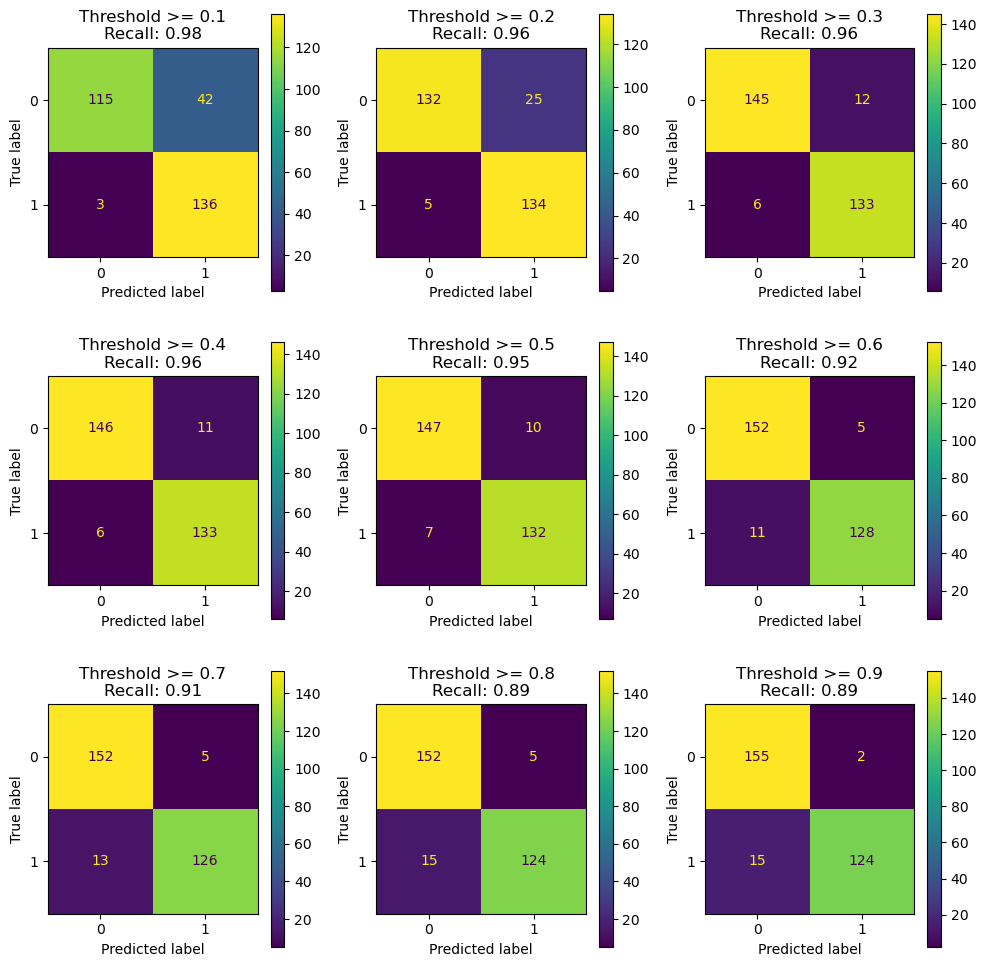

In [58]:
y_pred_proba_undersample = lr.predict_proba(X_test_undersample)

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for i, ax in zip(thresholds, axes.flat):
    y_test_predictions_high_recall = y_pred_proba_undersample[:, 1] > i

    recall = recall_score(y_test_undersample, y_test_predictions_high_recall)

    ConfusionMatrixDisplay.from_predictions(y_test_undersample, 
                                            y_test_predictions_high_recall,
                                            display_labels=[0, 1], 
                                            ax=ax)
    
    ax.set_title(f'Threshold >= {i}\nRecall: {recall:.2f}')

plt.tight_layout()
plt.show()

반면에 아래 코드는 전체 데이터셋으로 훈련된 모델의 재현율의 변화를 혼동행렬의 변화로 보여준다.

- 결정 임곗값을 0.9까지 올리면 재현율이 50%까지 떨어진다.

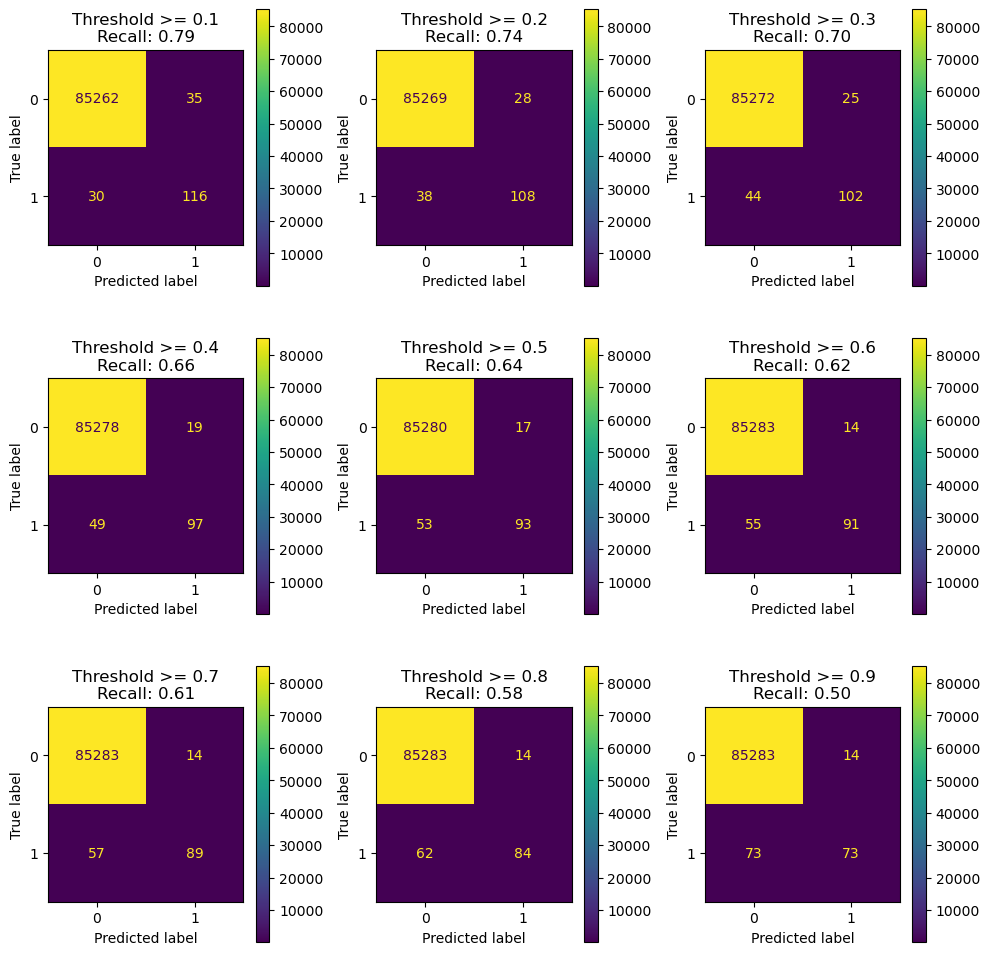

In [60]:
y_pred_proba_full = lr_full.predict_proba(X_test)

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for i, ax in zip(thresholds, axes.flat):
    y_test_predictions_high_recall = y_pred_proba_full[:, 1] > i

    recall = recall_score(y_test, y_test_predictions_high_recall)

    ConfusionMatrixDisplay.from_predictions(y_test, 
                                            y_test_predictions_high_recall,
                                            display_labels=[0, 1], 
                                            ax=ax)
    
    ax.set_title(f'Threshold >= {i}\nRecall: {recall:.2f}')

plt.tight_layout()
plt.show()